<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Importation des bibliotheques</T1>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from pathlib import Path
from scipy import stats
from scipy.stats import levene, bartlett, shapiro, mannwhitneyu, ttest_ind, spearmanr, pearsonr

In [9]:
# Configurations

# ── Découpage des périodes ───────────────────────────────
PERIODES = {
    'Avant (2010-2017)':       (2010, 2017),
    'Bande ±2.5% (2018-2019)': (2018, 2019),
    'Covid + ±5% (2020)':      (2020, 2020),
    'Après ±5% (2021-2025)':   (2021, 2025),
}

# ── Couleurs ─────────────────────────────────────────────
COLORS = {
    'avant':   '#1D4ED8',
    'bande25': '#D97706',
    'covid':   '#DC2626',
    'bande5':  '#065F46',
}

COLORS_LIGHT = {
    'avant':   '#BFDBFE',
    'bande25': '#FDE68A',
    'covid':   '#FECACA',
    'bande5':  '#A7F3D0',
}

PERIODE_BANDS = [
    (2010, 2017, '#DBEAFE', 'Avant'),
    (2018, 2019, '#FEF3C7', 'Bande ±2.5%'),
    (2020, 2020, '#FEE2E2', 'Covid'),
    (2021, 2025, '#D1FAE5', 'Bande ±5%'),
]

def add_bands(ax, is_date=True):
    for start, end, color, label in PERIODE_BANDS:
        if is_date:
            ax.axvspan(pd.Timestamp(f'{start}-01-01'),
                       pd.Timestamp(f'{end}-12-31'),
                       color=color, alpha=0.4, zorder=0)
        else:
            ax.axvspan(start - 0.4, end + 0.4,
                       color=color, alpha=0.4, zorder=0)
    ax.axvline(
        pd.Timestamp('2018-01-15') if is_date else 2018,
        color='#1D4ED8', linewidth=1.2,
        linestyle='--', zorder=5, label='Jan 2018 ±2.5%')
    ax.axvline(
        pd.Timestamp('2020-03-15') if is_date else 2020,
        color='#059669', linewidth=1.2,
        linestyle='--', zorder=5, label='Mar 2020 ±5%')

def legend_periodes():
    return [
        Patch(facecolor='#DBEAFE', label='Avant (2010-2017)'),
        Patch(facecolor='#FEF3C7', label='Bande ±2.5% (2018-2019)'),
        Patch(facecolor='#FEE2E2', label='Covid+±5% (2020)'),
        Patch(facecolor='#D1FAE5', label='Après ±5% (2021-2025)'),
        plt.Line2D([0],[0], color='#1D4ED8', linestyle='--', label='Jan 2018'),
        plt.Line2D([0],[0], color='#059669', linestyle='--', label='Mar 2020'),
    ]

def get_data(df, date_col, val_col, debut, fin):
    if df[date_col].dtype == 'object':
        df[date_col] = pd.to_datetime(df[date_col])
    mask = df[date_col].dt.year.between(debut, fin)
    return df.loc[mask, val_col].dropna().values

In [3]:
# Charger les données

data_dir = Path("..") / "data" / "cleaned"
csv_files = sorted([p for p in data_dir.iterdir()])
dfs = [pd.read_csv(p) for p in csv_files]
dfs_names = [p.stem for p in csv_files]
dfs_dict = dict(zip(dfs_names, dfs))

In [ ]:
# Reconvertir les dates

eur_mad = dfs_dict['taux_change (EUR)_cleaned'].copy()
usd_mad = dfs_dict['taux_change (USD)_cleaned'].copy()
eur_mad['Date'] = pd.to_datetime(eur_mad['Date'])
usd_mad['Date'] = pd.to_datetime(usd_mad['Date'])

masi = dfs_dict['masi_cleaned'].copy()
masi['Date'] = pd.to_datetime(masi['Date'])

In [10]:
# Afficher les périodes couvertes
print(f"  Périodes : {list(PERIODES.keys())}")
print(f"  EUR/MAD  : {eur_mad['Date'].min().date()} → {eur_mad['Date'].max().date()}")
print(f"  USD/MAD  : {usd_mad['Date'].min().date()} → {usd_mad['Date'].max().date()}")

  Périodes : ['Avant (2010-2017)', 'Bande ±2.5% (2018-2019)', 'Covid + ±5% (2020)', 'Après ±5% (2021-2025)']
  EUR/MAD  : 2010-01-01 → 2026-01-30
  USD/MAD  : 2010-01-01 → 2026-01-30


<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Test H1 — La volatilité du dirham augmente significativement après 2018</T1>

In [ ]:
# Extraction des variations
# On travaille sur EUR/MAD — devise principale pour H1

print("=" * 65)
print("H1 — La volatilité du dirham augmente après la réforme")
print("=" * 65)

# Extraire variations EUR/MAD par période
var_avant   = get_data(eur_mad, 'Date', 'Variation', 2010, 2017)
var_bande25 = get_data(eur_mad, 'Date', 'Variation', 2018, 2019)
var_covid   = get_data(eur_mad, 'Date', 'Variation', 2020, 2020)
var_bande5  = get_data(eur_mad, 'Date', 'Variation', 2021, 2025)

print(f"\n{'Période':<30} {'N obs':>6} {'Moyenne':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 68)
for label, data in [
    ('Avant (2010-2017)',       var_avant),
    ('Bande ±2.5% (2018-2019)', var_bande25),
    ('Covid+±5% (2020)',        var_covid),
    ('Après ±5% (2021-2025)',   var_bande5),
]:
    print(f"  {label:<28} {len(data):>6} {data.mean():>10.4f} "
          f"{data.std():>10.4f} {data.min():>10.4f} {data.max():>10.4f}")

H1 — La volatilité du dirham augmente après la réforme

Période                         N obs    Moyenne        Std        Min        Max
--------------------------------------------------------------------
  Avant (2010-2017)              2086    -0.0002     0.1949    -0.9500     1.4000
  Bande ±2.5% (2018-2019)         522    -0.0085     0.1764    -0.6800     0.5000
  Covid+±5% (2020)                262     0.0058     0.3142    -2.0600     1.4600
  Après ±5% (2021-2025)          1304    -0.0006     0.3248    -1.5700     1.5600


In [14]:
# Tests statistiques
alpha = 0.05

print("\n── Normalité (Shapiro-Wilk sur échantillon 500) ───────────")
for label, data in [
    ('Avant',       var_avant),
    ('±2.5%',       var_bande25),
    ('Covid',       var_covid),
    ('±5%',         var_bande5),
]:
    sample = data[:500] if len(data) > 500 else data
    stat, p = shapiro(sample)
    normal = "Normale" if p > alpha else "Non normale"
    print(f"  {label:<12} : W={stat:.4f} p={p:.6f} → {normal}")

print("\n── Tests de Levene (égalité des variances) ────────────────")
print(f"\n  {'Comparaison':<40} {'F':>8} {'p-value':>12} {'Décision':>15}")
print("  " + "-" * 78)

comparaisons = [
    ("Avant vs ±2.5% (2018-2019)",      var_avant, var_bande25),
    ("Avant vs Covid+±5% (2020)",        var_avant, var_covid),
    ("Avant vs Après ±5% (2021-2025)",   var_avant, var_bande5),
    ("±2.5% vs Après ±5%",              var_bande25, var_bande5),
]

resultats_H1 = {}
for label, g1, g2 in comparaisons:
    stat, p = levene(g1, g2)
    decision = "Rejeter H0 ✓" if p < alpha else "Garder H0 ✗"
    print(f"  {label:<40} {stat:>8.4f} {p:>12.6f}   {decision}")
    resultats_H1[label] = {'F': stat, 'p': p}

print("\n── Taille d'effet — ratio des écarts-types ────────────────")
print(f"  std Avant    = {var_avant.std():.4f}%  (référence)")
print(f"  std ±2.5%    = {var_bande25.std():.4f}%  → {var_bande25.std()/var_avant.std():.2f}x")
print(f"  std Covid    = {var_covid.std():.4f}%  → {var_covid.std()/var_avant.std():.2f}x")
print(f"  std ±5%      = {var_bande5.std():.4f}%  → {var_bande5.std()/var_avant.std():.2f}x")


── Normalité (Shapiro-Wilk sur échantillon 500) ───────────
  Avant        : W=0.9670 p=0.000000 → Non normale
  ±2.5%        : W=0.9975 p=0.647537 → Normale
  Covid        : W=0.8728 p=0.000000 → Non normale
  ±5%          : W=0.9850 p=0.000052 → Non normale

── Tests de Levene (égalité des variances) ────────────────

  Comparaison                                     F      p-value        Décision
  ------------------------------------------------------------------------------
  Avant vs ±2.5% (2018-2019)                 0.3055     0.580493   Garder H0 ✗
  Avant vs Covid+±5% (2020)                 39.7450     0.000000   Rejeter H0 ✓
  Avant vs Après ±5% (2021-2025)           273.8923     0.000000   Rejeter H0 ✓
  ±2.5% vs Après ±5%                       106.6259     0.000000   Rejeter H0 ✓

── Taille d'effet — ratio des écarts-types ────────────────
  std Avant    = 0.1949%  (référence)
  std ±2.5%    = 0.1764%  → 0.91x
  std Covid    = 0.3142%  → 1.61x
  std ±5%      = 0.3248%  → 1

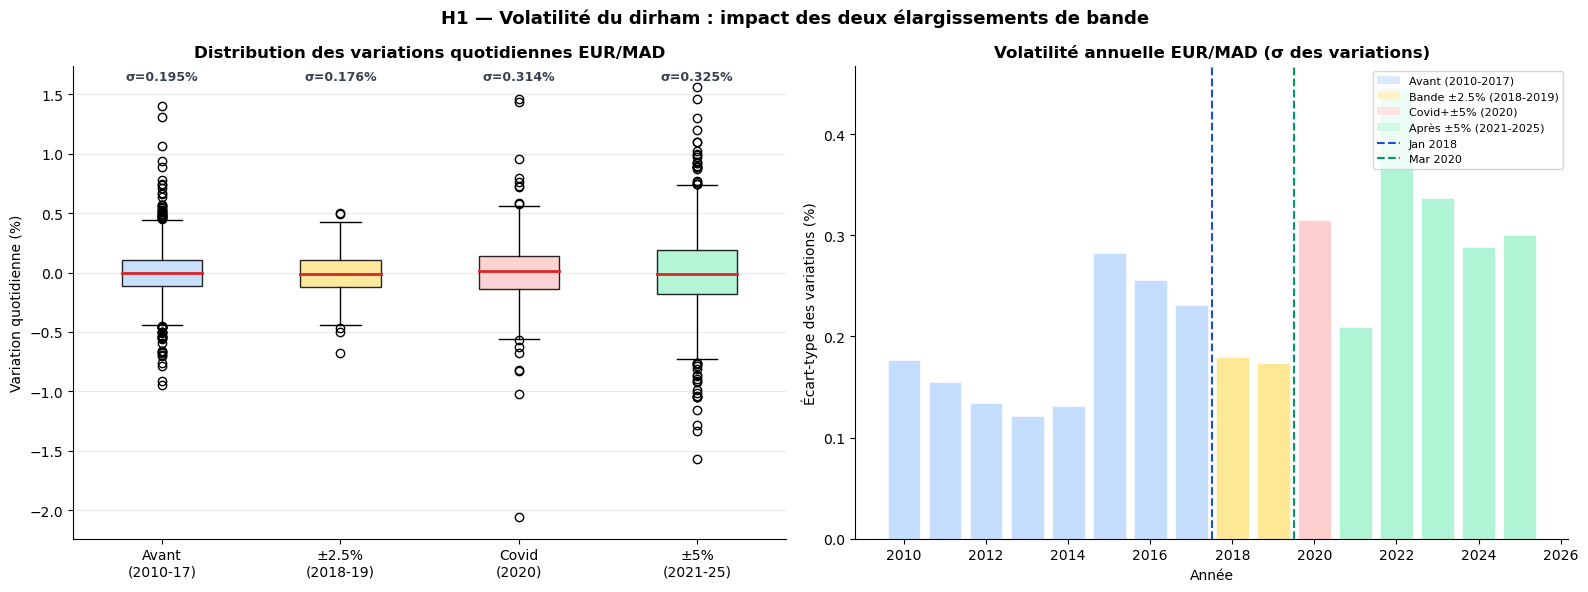

In [15]:
# Visualisation

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("H1 — Volatilité du dirham : impact des deux élargissements de bande",
             fontsize=13, fontweight='bold')

# Gauche — boxplot 4 périodes
ax = axes[0]
data_box = [var_avant, var_bande25, var_covid, var_bande5]
labels   = ['Avant\n(2010-17)', '±2.5%\n(2018-19)',
            'Covid\n(2020)', '±5%\n(2021-25)']
colors_b = list(COLORS_LIGHT.values())

bp = ax.boxplot(data_box, labels=labels, patch_artist=True,
                medianprops=dict(color='#DC2626', linewidth=2))
for patch, color in zip(bp['boxes'], colors_b):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for i, data in enumerate(data_box, 1):
    ax.text(i, ax.get_ylim()[1] * 0.93,
            f"σ={data.std():.3f}%",
            ha='center', fontsize=9, fontweight='bold', color='#374151')

ax.set_title("Distribution des variations quotidiennes EUR/MAD",
             fontweight='bold')
ax.set_ylabel("Variation quotidienne (%)")
ax.grid(axis='y', color='#E5E5E5', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Droite — volatilité annuelle
ax = axes[1]
vol_ann = (eur_mad.set_index('Date')['Variation']
           .resample('Y').std().reset_index())
vol_ann['Year'] = vol_ann['Date'].dt.year
vol_ann = vol_ann[vol_ann['Year'] <= 2025]

bar_colors = []
for y in vol_ann['Year']:
    if y <= 2017:   bar_colors.append(COLORS_LIGHT['avant'])
    elif y <= 2019: bar_colors.append(COLORS_LIGHT['bande25'])
    elif y == 2020: bar_colors.append(COLORS_LIGHT['covid'])
    else:           bar_colors.append(COLORS_LIGHT['bande5'])

bars = ax.bar(vol_ann['Year'], vol_ann['Variation'],
              color=bar_colors, alpha=0.9,
              edgecolor='white', linewidth=0.5)

ax.axvline(2017.5, color='#1D4ED8', linewidth=1.5,
           linestyle='--', label='Jan 2018 — ±2.5%')
ax.axvline(2019.5, color='#059669', linewidth=1.5,
           linestyle='--', label='Mar 2020 — ±5%')

ax.set_title("Volatilité annuelle EUR/MAD (σ des variations)",
             fontweight='bold')
ax.set_ylabel("Écart-type des variations (%)")
ax.set_xlabel("Année")
ax.legend(handles=legend_periodes(), fontsize=8, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../visualisation/viz_H1_volatilite.png",
            bbox_inches='tight', dpi=150)
plt.show()

In [16]:
# Conclusion

p_avant_bande25 = resultats_H1["Avant vs ±2.5% (2018-2019)"]['p']
p_avant_bande5  = resultats_H1["Avant vs Après ±5% (2021-2025)"]['p']
p_bande25_bande5 = resultats_H1["±2.5% vs Après ±5%"]['p']

print("=" * 65)
print("CONCLUSION — H1")
print("=" * 65)
print(f"""
Hypothèse : La volatilité du dirham augmente significativement
            après la réforme de change.

Écarts-types par période :
  Avant    (2010-2017) : {var_avant.std():.4f}%  (référence)
  ±2.5%    (2018-2019) : {var_bande25.std():.4f}%  ({var_bande25.std()/var_avant.std():.2f}x)
  Covid    (2020)      : {var_covid.std():.4f}%  ({var_covid.std()/var_avant.std():.2f}x)
  ±5%      (2021-2025) : {var_bande5.std():.4f}%  ({var_bande5.std()/var_avant.std():.2f}x)

Tests de Levene (α = 0.05) :
  Avant vs ±2.5%  : p = {p_avant_bande25:.6f} → {'Significatif ✓' if p_avant_bande25 < 0.05 else 'Non significatif ✗'}
  Avant vs ±5%    : p = {p_avant_bande5:.6f}  → {'Significatif ✓' if p_avant_bande5 < 0.05 else 'Non significatif ✗'}
  ±2.5% vs ±5%   : p = {p_bande25_bande5:.6f}  → {'Significatif ✓' if p_bande25_bande5 < 0.05 else 'Non significatif ✗'}

Décision finale :
  H1 {'CONFIRMÉE ✓' if p_avant_bande5 < 0.05 else 'NON CONFIRMÉE ✗'}

Notes :
  - 2020 isolé (Covid-19 + élargissement simultanés)
  - L'augmentation progressive de la volatilité entre
    ±2.5% et ±5% reflète l'élargissement graduel de la bande
""")

CONCLUSION — H1

Hypothèse : La volatilité du dirham augmente significativement
            après la réforme de change.

Écarts-types par période :
  Avant    (2010-2017) : 0.1949%  (référence)
  ±2.5%    (2018-2019) : 0.1764%  (0.91x)
  Covid    (2020)      : 0.3142%  (1.61x)
  ±5%      (2021-2025) : 0.3248%  (1.67x)

Tests de Levene (α = 0.05) :
  Avant vs ±2.5%  : p = 0.580493 → Non significatif ✗
  Avant vs ±5%    : p = 0.000000  → Significatif ✓
  ±2.5% vs ±5%   : p = 0.000000  → Significatif ✓

Décision finale :
  H1 CONFIRMÉE ✓

Notes :
  - 2020 isolé (Covid-19 + élargissement simultanés)
  - L'augmentation progressive de la volatilité entre
    ±2.5% et ±5% reflète l'élargissement graduel de la bande



<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Test H2 —  La libéralisation du taux de change a un impact positif sur les flux d’IDE à moyen terme</T1>

In [17]:
# Extraction et stats descriptives

print("=" * 65)
print("H2 — Impact de la libéralisation sur les flux d'IDE")
print("=" * 65)

ide = dfs_dict['ide_global_cleaned'].copy()

# Extraire IDE par période
def get_ide(debut, fin):
    mask = ide['Year'].between(debut, fin)
    return ide.loc[mask, 'IDE_USD'].dropna().values / 1e9  # en Mrd USD

ide_avant   = get_ide(2010, 2017)
ide_bande25 = get_ide(2018, 2019)
ide_covid   = get_ide(2020, 2020)
ide_bande5  = get_ide(2021, 2025)

print(f"\n{'Période':<30} {'N':>4} {'Moyenne':>10} {'Médiane':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 78)
for label, data in [
    ('Avant (2010-2017)',       ide_avant),
    ('Bande ±2.5% (2018-2019)', ide_bande25),
    ('Covid+±5% (2020)',        ide_covid),
    ('Après ±5% (2021-2025)',   ide_bande5),
]:
    print(f"  {label:<28} {len(data):>4} {data.mean():>10.3f} "
          f"{np.median(data):>10.3f} {data.std():>10.3f} "
          f"{data.min():>10.3f} {data.max():>10.3f}")
print("  (valeurs en Mrd USD)")

H2 — Impact de la libéralisation sur les flux d'IDE

Période                           N    Moyenne    Médiane        Std        Min        Max
------------------------------------------------------------------------------
  Avant (2010-2017)               8      2.697      2.761      0.699      1.241      3.525
  Bande ±2.5% (2018-2019)         2      2.633      2.633      0.912      1.721      3.544
  Covid+±5% (2020)                1      1.419      1.419      0.000      1.419      1.419
  Après ±5% (2021-2025)           4      1.814      1.952      0.508      1.060      2.294
  (valeurs en Mrd USD)


In [18]:
# Tests statistiques

alpha = 0.05

# ── Normalité ────────────────────────────────────────────
print("── Normalité (Shapiro-Wilk) ───────────────────────────────")
for label, data in [
    ('Avant',   ide_avant),
    ('±2.5%',   ide_bande25),
    ('±5%',     ide_bande5),
]:
    if len(data) >= 3:
        stat, p = shapiro(data)
        normal = "Normale" if p > alpha else "Non normale"
        print(f"  {label:<12} : n={len(data)} W={stat:.4f} p={p:.4f} → {normal}")
    else:
        print(f"  {label:<12} : n={len(data)} → trop peu d'obs pour Shapiro")

# ── Tests de comparaison ─────────────────────────────────
print("\n── Tests de comparaison des moyennes ──────────────────────")
print(f"\n  {'Comparaison':<35} {'Test':>12} {'Stat':>8} {'p-value':>12} {'Décision':>15}")
print("  " + "-" * 85)

comparaisons_H2 = [
    ("Avant vs ±2.5% (2018-2019)", ide_avant, ide_bande25),
    ("Avant vs ±5%   (2021-2024)", ide_avant, ide_bande5),
    ("±2.5% vs ±5%",               ide_bande25, ide_bande5),
]

resultats_H2 = {}
for label, g1, g2 in comparaisons_H2:
    # Choisir le test selon la taille d'échantillon
    # n petit → Mann-Whitney plus robuste
    stat_mw, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
    decision = "Rejeter H0 ✓" if p_mw < alpha else "Garder H0 ✗"
    print(f"  {label:<35} {'Mann-Whitney':>12} {stat_mw:>8.1f} {p_mw:>12.4f}   {decision}")
    resultats_H2[label] = {'stat': stat_mw, 'p': p_mw}

# ── Taille d'effet ───────────────────────────────────────
print("\n── Taille d'effet ─────────────────────────────────────────")
print(f"  Moyenne Avant    = {ide_avant.mean():.3f} Mrd USD")
print(f"  Moyenne ±2.5%    = {ide_bande25.mean():.3f} Mrd USD → "
      f"{'hausse' if ide_bande25.mean() > ide_avant.mean() else 'baisse'} "
      f"de {abs(ide_bande25.mean()-ide_avant.mean())/ide_avant.mean()*100:.1f}%")
print(f"  Moyenne ±5%      = {ide_bande5.mean():.3f} Mrd USD → "
      f"{'hausse' if ide_bande5.mean() > ide_avant.mean() else 'baisse'} "
      f"de {abs(ide_bande5.mean()-ide_avant.mean())/ide_avant.mean()*100:.1f}%")
print(f"  Covid 2020       = {ide_covid.mean():.3f} Mrd USD (référence Covid)")

── Normalité (Shapiro-Wilk) ───────────────────────────────
  Avant        : n=8 W=0.9261 p=0.4811 → Normale
  ±2.5%        : n=2 → trop peu d'obs pour Shapiro
  ±5%          : n=4 W=0.8783 p=0.3316 → Normale

── Tests de comparaison des moyennes ──────────────────────

  Comparaison                                 Test     Stat      p-value        Décision
  -------------------------------------------------------------------------------------
  Avant vs ±2.5% (2018-2019)          Mann-Whitney      7.0       0.8889   Garder H0 ✗
  Avant vs ±5%   (2021-2024)          Mann-Whitney     27.0       0.0727   Garder H0 ✗
  ±2.5% vs ±5%                        Mann-Whitney      6.0       0.5333   Garder H0 ✗

── Taille d'effet ─────────────────────────────────────────
  Moyenne Avant    = 2.697 Mrd USD
  Moyenne ±2.5%    = 2.633 Mrd USD → baisse de 2.4%
  Moyenne ±5%      = 1.814 Mrd USD → baisse de 32.7%
  Covid 2020       = 1.419 Mrd USD (référence Covid)


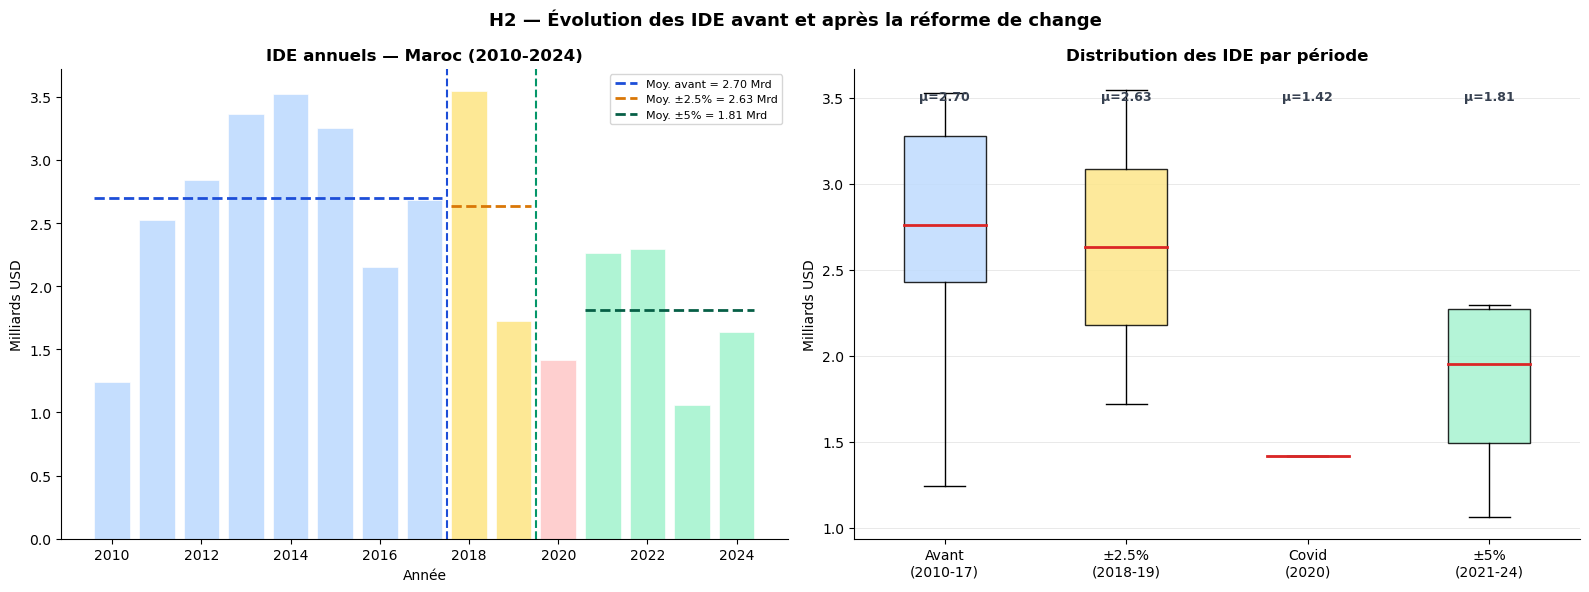

In [19]:
# Visualisation

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("H2 — Évolution des IDE avant et après la réforme de change",
             fontsize=13, fontweight='bold')

# Gauche — IDE annuel en barres
ax = axes[0]
bar_colors = []
for y in ide['Year']:
    if y <= 2017:   bar_colors.append(COLORS_LIGHT['avant'])
    elif y <= 2019: bar_colors.append(COLORS_LIGHT['bande25'])
    elif y == 2020: bar_colors.append(COLORS_LIGHT['covid'])
    else:           bar_colors.append(COLORS_LIGHT['bande5'])

ax.bar(ide['Year'], ide['IDE_USD'] / 1e9,
       color=bar_colors, alpha=0.9,
       edgecolor='white', linewidth=0.5)

# Ligne de moyenne par période
for debut, fin, color, label in [
    (2010, 2017, COLORS['avant'],   'Moy. avant'),
    (2018, 2019, COLORS['bande25'], 'Moy. ±2.5%'),
    (2021, 2024, COLORS['bande5'],  'Moy. ±5%'),
]:
    moy = ide[ide['Year'].between(debut, fin)]['IDE_USD'].mean() / 1e9
    ax.hlines(moy, debut - 0.4, fin + 0.4,
              colors=color, linewidth=2,
              linestyles='--', label=f'{label} = {moy:.2f} Mrd')

ax.axvline(2017.5, color='#1D4ED8', linewidth=1.5, linestyle='--')
ax.axvline(2019.5, color='#059669', linewidth=1.5, linestyle='--')
ax.set_title("IDE annuels — Maroc (2010-2024)", fontweight='bold')
ax.set_ylabel("Milliards USD")
ax.set_xlabel("Année")
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Droite — boxplot par période
ax = axes[1]
data_box = [ide_avant, ide_bande25, ide_covid, ide_bande5]
labels   = ['Avant\n(2010-17)', '±2.5%\n(2018-19)',
            'Covid\n(2020)', '±5%\n(2021-24)']

bp = ax.boxplot(data_box, labels=labels, patch_artist=True,
                medianprops=dict(color='#DC2626', linewidth=2))
for patch, color in zip(bp['boxes'], list(COLORS_LIGHT.values())):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for i, data in enumerate(data_box, 1):
    ax.text(i, ax.get_ylim()[1] * 0.95,
            f"μ={data.mean():.2f}",
            ha='center', fontsize=9,
            fontweight='bold', color='#374151')

ax.set_title("Distribution des IDE par période", fontweight='bold')
ax.set_ylabel("Milliards USD")
ax.grid(axis='y', color='#E5E5E5', linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../visualisation/viz_H2_ide.png",
            bbox_inches='tight', dpi=150)
plt.show()

In [20]:
#  Conclusion

p_avant_bande25 = resultats_H2["Avant vs ±2.5% (2018-2019)"]['p']
p_avant_bande5  = resultats_H2["Avant vs ±5%   (2021-2024)"]['p']

print("=" * 65)
print("CONCLUSION — H2")
print("=" * 65)
print(f"""
Hypothèse : La libéralisation du taux de change a un impact
            positif sur les flux d'IDE à moyen terme.

Moyennes par période :
  Avant    (2010-2017) : {ide_avant.mean():.3f} Mrd USD  (référence)
  ±2.5%    (2018-2019) : {ide_bande25.mean():.3f} Mrd USD
  Covid    (2020)      : {ide_covid.mean():.3f} Mrd USD
  ±5%      (2021-2024) : {ide_bande5.mean():.3f} Mrd USD

Tests Mann-Whitney (α = 0.05) :
  Avant vs ±2.5% : p = {p_avant_bande25:.4f} → {'Significatif ✓' if p_avant_bande25 < alpha else 'Non significatif ✗'}
  Avant vs ±5%   : p = {p_avant_bande5:.4f}  → {'Significatif ✓' if p_avant_bande5 < alpha else 'Non significatif ✗'}

Décision finale :
  H2 {'CONFIRMÉE ✓' if p_avant_bande5 < alpha and ide_bande5.mean() > ide_avant.mean() else 'NON CONFIRMÉE ✗'}

Limites :
  - Petit échantillon (n=8 avant, n=4 après) → puissance limitée
  - La baisse des IDE commence en 2015, avant la réforme
  - Facteurs confondants : Covid 2020, contexte mondial
  - Conclusion prudente — la réforme seule ne peut pas
    expliquer l'évolution des IDE
""")

CONCLUSION — H2

Hypothèse : La libéralisation du taux de change a un impact
            positif sur les flux d'IDE à moyen terme.

Moyennes par période :
  Avant    (2010-2017) : 2.697 Mrd USD  (référence)
  ±2.5%    (2018-2019) : 2.633 Mrd USD
  Covid    (2020)      : 1.419 Mrd USD
  ±5%      (2021-2024) : 1.814 Mrd USD

Tests Mann-Whitney (α = 0.05) :
  Avant vs ±2.5% : p = 0.8889 → Non significatif ✗
  Avant vs ±5%   : p = 0.0727  → Non significatif ✗

Décision finale :
  H2 NON CONFIRMÉE ✗

Limites :
  - Petit échantillon (n=8 avant, n=4 après) → puissance limitée
  - La baisse des IDE commence en 2015, avant la réforme
  - Facteurs confondants : Covid 2020, contexte mondial
  - Conclusion prudente — la réforme seule ne peut pas
    expliquer l'évolution des IDE



In [ ]:
# Analyses sectorielles

ide_s = dfs_dict['ide_secteur_cleaned'].copy()

SECTEURS = [c for c in ide_s.columns if c not in ['Year', 'TOTAL']]

print("=" * 65)
print("H2 — Impact de la libéralisation sur les IDE (par secteur)")
print("=" * 65)

# Extraire TOTAL par période
def get_ide_s(debut, fin):
    return ide_s[ide_s['Year'].between(debut, fin)]['TOTAL'].values

ide_avant   = get_ide_s(2010, 2017)
ide_bande25 = get_ide_s(2018, 2019)
ide_covid   = get_ide_s(2020, 2020)
ide_bande5  = get_ide_s(2021, 2025)

print(f"\n{'Période':<30} {'N':>4} {'Moyenne':>12} {'Médiane':>12} {'Std':>10}")
print("-" * 70)
for label, data in [
    ('Avant (2010-2017)',        ide_avant),
    ('Bande ±2.5% (2018-2019)', ide_bande25),
    ('Covid+±5% (2020)',         ide_covid),
    ('Après ±5% (2021-2025)',    ide_bande5),
]:
    print(f"  {label:<28} {len(data):>4} "
          f"{data.mean():>12.1f} {np.median(data):>12.1f} "
          f"{data.std():>10.1f}")
print("  (valeurs en Millions MAD)")

# Évolution par secteur entre avant et après
print(f"\n── Évolution des secteurs : Avant vs Après ±5% ────────────")
print(f"  {'Secteur':<25} {'Moy Avant':>12} {'Moy ±5%':>12} {'Variation':>12}")
print("  " + "-" * 65)

evolutions = []
for s in SECTEURS:
    moy_avant = ide_s[ide_s['Year'].between(2010, 2017)][s].mean()
    moy_bande5 = ide_s[ide_s['Year'].between(2021, 2025)][s].mean()
    var = (moy_bande5 - moy_avant) / moy_avant * 100
    evolutions.append((s, moy_avant, moy_bande5, var))

evolutions.sort(key=lambda x: x[3], reverse=True)
for s, ma, mb, v in evolutions:
    signe = "▲" if v > 0 else "▼"
    print(f"  {s:<25} {ma:>12.1f} {mb:>12.1f} {signe}{abs(v):>10.1f}%")

H2 — Impact de la libéralisation sur les IDE (par secteur)

Période                           N      Moyenne      Médiane        Std
----------------------------------------------------------------------
  Avant (2010-2017)               8      34809.0      35209.8     4059.9
  Bande ±2.5% (2018-2019)         2      40294.0      40294.0     5805.0
  Covid+±5% (2020)                1      26005.0      26005.0        0.0
  Après ±5% (2021-2025)           5      39998.0      40297.0     4082.4
  (valeurs en Millions MAD)

── Évolution des secteurs : Avant vs Après ±5% ────────────
  Secteur                      Moy Avant      Moy ±5%    Variation
  -----------------------------------------------------------------
  Agriculture                      207.7        753.0 ▲     262.5%
  Transports                       634.5       1672.6 ▲     163.6%
  Pêche                             23.2         58.0 ▲     150.4%
  Industrie                       8688.2      14229.6 ▲      63.8%
  Autres ser

In [22]:
# Tests statistiques

alpha = 0.05

print("\n── Tests Mann-Whitney — TOTAL IDE ─────────────────────────")
print(f"\n  {'Comparaison':<35} {'Stat':>8} {'p-value':>12} {'Décision':>15}")
print("  " + "-" * 75)

comparaisons_H2 = [
    ("Avant vs ±2.5% (2018-2019)", ide_avant, ide_bande25),
    ("Avant vs ±5%   (2021-2025)", ide_avant, ide_bande5),
    ("±2.5% vs ±5%",               ide_bande25, ide_bande5),
]

resultats_H2 = {}
for label, g1, g2 in comparaisons_H2:
    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    decision = "Rejeter H0 ✓" if p < alpha else "Garder H0 ✗"
    print(f"  {label:<35} {stat:>8.1f} {p:>12.4f}   {decision}")
    resultats_H2[label] = {'stat': stat, 'p': p}

# Test par secteur — Avant vs Après ±5%
print(f"\n── Tests par secteur : Avant vs Après ±5% ─────────────────")
print(f"  {'Secteur':<25} {'p-value':>12} {'Décision':>15} {'Direction':>12}")
print("  " + "-" * 68)

for s in SECTEURS:
    g1 = ide_s[ide_s['Year'].between(2010, 2017)][s].values
    g2 = ide_s[ide_s['Year'].between(2021, 2025)][s].values
    try:
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        decision = "Sig. ✓" if p < alpha else "Non sig. ✗"
        direction = "↑ Hausse" if g2.mean() > g1.mean() else "↓ Baisse"
        print(f"  {s:<25} {p:>12.4f}   {decision:<15} {direction:>12}")
    except:
        print(f"  {s:<25} {'N/A':>12}")


── Tests Mann-Whitney — TOTAL IDE ─────────────────────────

  Comparaison                             Stat      p-value        Décision
  ---------------------------------------------------------------------------
  Avant vs ±2.5% (2018-2019)               5.0       0.5333   Garder H0 ✗
  Avant vs ±5%   (2021-2025)               7.0       0.0653   Garder H0 ✗
  ±2.5% vs ±5%                             6.0       0.8571   Garder H0 ✗

── Tests par secteur : Avant vs Après ±5% ─────────────────
  Secteur                        p-value        Décision    Direction
  --------------------------------------------------------------------
  Agriculture                     0.0016   Sig. ✓              ↑ Hausse
  Assurance                       0.8329   Non sig. ✗          ↓ Baisse
  Autres services                 0.0186   Sig. ✓              ↑ Hausse
  Banque                          0.5237   Non sig. ✗          ↓ Baisse
  Commerce                        0.2844   Non sig. ✗          ↑ Hausse


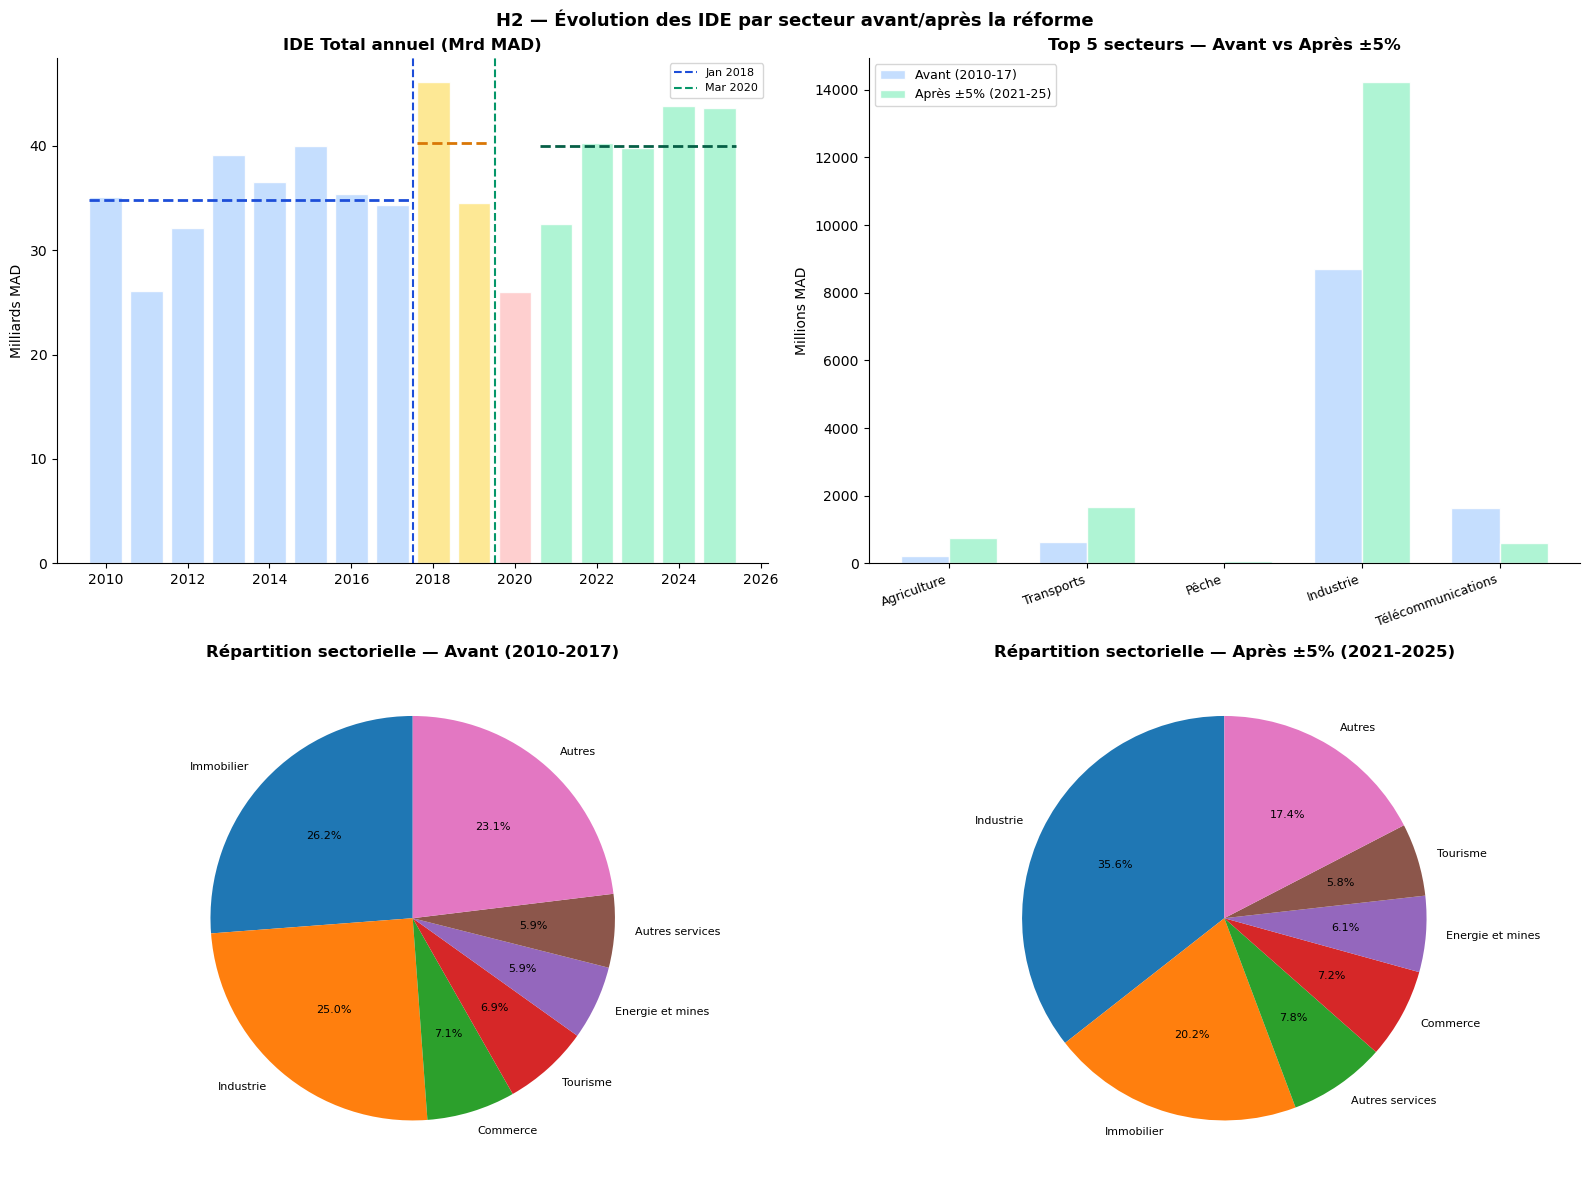

In [23]:
# Visualisation

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("H2 — Évolution des IDE par secteur avant/après la réforme",
             fontsize=13, fontweight='bold')

# Haut gauche — TOTAL annuel
ax = axes[0, 0]
bar_colors = []
for y in ide_s['Year']:
    if y <= 2017:   bar_colors.append(COLORS_LIGHT['avant'])
    elif y <= 2019: bar_colors.append(COLORS_LIGHT['bande25'])
    elif y == 2020: bar_colors.append(COLORS_LIGHT['covid'])
    else:           bar_colors.append(COLORS_LIGHT['bande5'])

ax.bar(ide_s['Year'], ide_s['TOTAL'] / 1000,
       color=bar_colors, alpha=0.9, edgecolor='white')

for debut, fin, color in [
    (2010, 2017, COLORS['avant']),
    (2018, 2019, COLORS['bande25']),
    (2021, 2025, COLORS['bande5']),
]:
    moy = ide_s[ide_s['Year'].between(debut, fin)]['TOTAL'].mean() / 1000
    ax.hlines(moy, debut - 0.4, fin + 0.4,
              colors=color, linewidth=2, linestyles='--')

ax.axvline(2017.5, color='#1D4ED8', linewidth=1.5, linestyle='--', label='Jan 2018')
ax.axvline(2019.5, color='#059669', linewidth=1.5, linestyle='--', label='Mar 2020')
ax.set_title("IDE Total annuel (Mrd MAD)", fontweight='bold')
ax.set_ylabel("Milliards MAD")
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Haut droite — Top 5 secteurs évolution
ax = axes[0, 1]
top5 = sorted(evolutions, key=lambda x: abs(x[3]), reverse=True)[:5]
secteurs_top = [e[0] for e in top5]
moy_avant_top = [e[1] for e in top5]
moy_bande5_top = [e[2] for e in top5]

x = np.arange(len(secteurs_top))
w = 0.35
ax.bar(x - w/2, moy_avant_top, w,
       color=COLORS_LIGHT['avant'], label='Avant (2010-17)',
       edgecolor='white', alpha=0.9)
ax.bar(x + w/2, moy_bande5_top, w,
       color=COLORS_LIGHT['bande5'], label='Après ±5% (2021-25)',
       edgecolor='white', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(secteurs_top, rotation=20, ha='right', fontsize=9)
ax.set_title("Top 5 secteurs — Avant vs Après ±5%", fontweight='bold')
ax.set_ylabel("Millions MAD")
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bas gauche — Répartition sectorielle Avant
ax = axes[1, 0]
moy_avant_sect = {s: ide_s[ide_s['Year'].between(2010,2017)][s].mean()
                  for s in SECTEURS}
top_secteurs = sorted(moy_avant_sect, key=moy_avant_sect.get, reverse=True)[:6]
autres = sum(v for k,v in moy_avant_sect.items() if k not in top_secteurs)
vals = [moy_avant_sect[s] for s in top_secteurs] + [autres]
lbls = top_secteurs + ['Autres']
ax.pie(vals, labels=lbls, autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 8})
ax.set_title("Répartition sectorielle — Avant (2010-2017)", fontweight='bold')

# Bas droite — Répartition sectorielle Après ±5%
ax = axes[1, 1]
moy_bande5_sect = {s: ide_s[ide_s['Year'].between(2021,2025)][s].mean()
                   for s in SECTEURS}
top_secteurs2 = sorted(moy_bande5_sect, key=moy_bande5_sect.get, reverse=True)[:6]
autres2 = sum(v for k,v in moy_bande5_sect.items() if k not in top_secteurs2)
vals2 = [moy_bande5_sect[s] for s in top_secteurs2] + [autres2]
lbls2 = top_secteurs2 + ['Autres']
ax.pie(vals2, labels=lbls2, autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 8})
ax.set_title("Répartition sectorielle — Après ±5% (2021-2025)", fontweight='bold')

plt.tight_layout()
plt.savefig("../visualisation/viz_H2_ide_secteur.png",
            bbox_inches='tight', dpi=150)
plt.show()

In [24]:
# Conclusion


p_avant_bande5 = resultats_H2["Avant vs ±5%   (2021-2025)"]['p']
p_avant_bande25 = resultats_H2["Avant vs ±2.5% (2018-2019)"]['p']

print("=" * 65)
print("CONCLUSION — H2")
print("=" * 65)
print(f"""
Hypothèse : La libéralisation a un impact positif sur les IDE.

IDE Total par période (Millions MAD) :
  Avant    (2010-2017) : {ide_avant.mean():>8.1f}  (référence)
  ±2.5%    (2018-2019) : {ide_bande25.mean():>8.1f}
  Covid    (2020)      : {ide_covid.mean():>8.1f}
  ±5%      (2021-2025) : {ide_bande5.mean():>8.1f}
  Variation Avant→±5%  : {(ide_bande5.mean()-ide_avant.mean())/ide_avant.mean()*100:>+.1f}%

Tests Mann-Whitney (α = 0.05) :
  Avant vs ±2.5% : p = {p_avant_bande25:.4f} → {'Significatif ✓' if p_avant_bande25 < alpha else 'Non significatif ✗'}
  Avant vs ±5%   : p = {p_avant_bande5:.4f}  → {'Significatif ✓' if p_avant_bande5 < alpha else 'Non significatif ✗'}

Secteurs les plus dynamiques après la réforme :
""")

for s, ma, mb, v in evolutions[:3]:
    print(f"  ▲ {s:<20} : +{v:.1f}%")
print()
for s, ma, mb, v in evolutions[-3:]:
    print(f"  ▼ {s:<20} : {v:.1f}%")

print(f"""
Décision : H2 {'CONFIRMÉE ✓' if p_avant_bande5 < alpha and
               ide_bande5.mean() > ide_avant.mean()
               else 'NON CONFIRMÉE ✗'}

Limites :
  - Données 2024* et 2025 provisoires
  - Petit échantillon par période (n=8 avant, n=5 après)
  - Facteurs confondants non contrôlés (Covid, conjoncture)
""")

CONCLUSION — H2

Hypothèse : La libéralisation a un impact positif sur les IDE.

IDE Total par période (Millions MAD) :
  Avant    (2010-2017) :  34809.0  (référence)
  ±2.5%    (2018-2019) :  40294.0
  Covid    (2020)      :  26005.0
  ±5%      (2021-2025) :  39998.0
  Variation Avant→±5%  : +14.9%

Tests Mann-Whitney (α = 0.05) :
  Avant vs ±2.5% : p = 0.5333 → Non significatif ✗
  Avant vs ±5%   : p = 0.0653  → Non significatif ✗

Secteurs les plus dynamiques après la réforme :

  ▲ Agriculture          : +262.5%
  ▲ Transports           : +163.6%
  ▲ Pêche                : +150.4%

  ▼ Grands travaux       : -34.6%
  ▼ Assurance            : -37.6%
  ▼ Télécommunications   : -62.8%

Décision : H2 NON CONFIRMÉE ✗

Limites :
  - Données 2024* et 2025 provisoires
  - Petit échantillon par période (n=8 avant, n=5 après)
  - Facteurs confondants non contrôlés (Covid, conjoncture)

